# Value at Risk and Conditional Value at Risk
**Docker image**: `ml4t`

## Purpose
Demonstrate VaR and CVaR computation methods - historical, parametric, Cornish-Fisher, and
Monte Carlo - on real ETF returns, then backtest them against realized losses, decompose
diversification benefit on a multi-asset portfolio, and contrast tail risk across volatility
regimes. These tail measures form the foundation for risk budgeting, exposure control, and
regulatory reporting.

## Learning Objectives
After completing this notebook, you will be able to:
- Compute VaR and CVaR with historical, parametric, Cornish-Fisher, and Monte Carlo methods
- Backtest VaR estimates with the Kupiec proportion-of-failures test
- Quantify the diversification benefit on a multi-asset ETF portfolio
- Decompose tail risk into volatility regimes and contrast forecast losses

## Book reference
- Section 19.3 - Measuring the Tail: VaR and CVaR
- Section 19.4 - Drawdowns, Path Risk, and Time-to-Recovery (drawdown context)

## Prerequisites
- Familiarity with daily return series and rolling volatility estimates
- Comfort reading quantile-based loss metrics and backtest exception counts

In [1]:
"""Value at Risk and Conditional Value at Risk on real ETF returns."""

import json
import logging
import warnings

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from arch import arch_model
from IPython.display import Markdown, display
from ml4t.diagnostic.evaluation.distribution import analyze_distribution
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")
logging.disable(logging.INFO)

In [2]:
SYMBOL = "SPY"
SEED = 42
PORTFOLIO_SYMBOLS = ["SPY", "AGG", "GLD", "EFA", "EEM"]
START_DATE = "2006-01-01"
END_DATE = "2024-12-31"
ROLLING_WINDOW = 252
REGIME_WINDOW = 63
REGIME_MIN_HISTORY = 252
FORECAST_EVALUATION_START = "2020-01-02"
N_MC_SIMULATIONS = 10_000

In [3]:
OUTPUT_DIR = get_output_dir(19, "var_cvar")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
set_global_seeds(SEED)

## 1. Load ETF returns

We use SPY for the single-asset VaR analysis and a diversified five-ETF basket
(US equities, US aggregate bonds, gold, developed international, emerging markets)
for the portfolio-level diversification benefit.

In [5]:
etf_panel = (
    load_etfs()
    .filter(
        (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
        & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
        & pl.col("symbol").is_in(PORTFOLIO_SYMBOLS)
    )
    .sort(["symbol", "timestamp"])
)

returns_panel = (
    etf_panel.with_columns(ret=(pl.col("close") / pl.col("close").shift(1) - 1).over("symbol"))
    .drop_nulls("ret")
    .select(["timestamp", "symbol", "ret"])
)

# Single-asset path uses the full SPY history. The portfolio-VaR section below
# uses returns_wide, which intersects calendars across all five ETFs.
returns_spy = (
    returns_panel.filter(pl.col("symbol") == SYMBOL).sort("timestamp").select(["timestamp", "ret"])
)
returns_wide = returns_panel.pivot(values="ret", index="timestamp", on="symbol").drop_nulls()
print(f"Loaded {returns_spy.height:,} {SYMBOL} daily returns (single-asset path)")
print(
    f"Loaded {returns_wide.height:,} aligned daily returns across "
    f"{len(PORTFOLIO_SYMBOLS)} ETFs (portfolio path)"
)
print(f"  {SYMBOL}: {returns_spy['timestamp'].min()} to {returns_spy['timestamp'].max()}")
print(
    f"  Portfolio (aligned): {returns_wide['timestamp'].min()} to {returns_wide['timestamp'].max()}"
)

dates = returns_spy["timestamp"].to_numpy()
returns = returns_spy["ret"].to_numpy()
N_DAYS = len(returns)

Loaded 4,780 SPY daily returns (single-asset path)
Loaded 4,780 aligned daily returns across 5 ETFs (portfolio path)
  SPY: 2006-01-04 to 2024-12-31
  Portfolio (aligned): 2006-01-04 to 2024-12-31


In [6]:
summary_stats = pl.DataFrame(
    {
        "metric": ["Mean (%)", "Std (%)", "Skewness", "Excess kurtosis"],
        SYMBOL: [
            np.mean(returns) * 100,
            np.std(returns) * 100,
            stats.skew(returns),
            stats.kurtosis(returns),
        ],
    }
).with_columns(pl.col(SYMBOL).round(4))
summary_stats

metric,SPY
str,f64
"""Mean (%)""",0.047
"""Std (%)""",1.2209
"""Skewness""",-0.0809
"""Excess kurtosis""",14.5477


## 2. VaR Computation Methods

Each method recovers the same loss quantile from a different distributional lens.
Historical VaR is non-parametric, parametric VaR assumes Gaussian returns,
Cornish-Fisher adjusts the Gaussian quantile for skewness and kurtosis, and Monte
Carlo VaR samples from a fitted Student-t distribution to capture heavy tails.

### Historical VaR

Historical VaR uses the empirical return distribution without imposing a parametric shape.

In [7]:
def historical_var(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Historical (non-parametric) VaR: $\\text{VaR}_\\alpha = -q_{1-\\alpha}(r)$."""
    alpha = 1 - confidence
    return -np.percentile(returns, alpha * 100)

### Parametric VaR

Gaussian VaR provides a compact benchmark when we assume returns are approximately normal.

In [8]:
def parametric_var(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Parametric (Gaussian) VaR: $-\\mu + \\sigma\\,\\Phi^{-1}(1-\\alpha)$."""
    mu = np.mean(returns)
    sigma = np.std(returns)
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha)
    return -(mu - z * sigma)

### Cornish-Fisher VaR

Cornish-Fisher VaR adjusts the Gaussian quantile for skewness and kurtosis.

In [9]:
def cornish_fisher_var(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Cornish-Fisher VaR with a skew/kurtosis adjustment to the Gaussian quantile."""
    mu = np.mean(returns)
    sigma = np.std(returns)
    s = stats.skew(returns)
    k = stats.kurtosis(returns)

    alpha = 1 - confidence
    z = stats.norm.ppf(alpha)
    z_cf = z + (z**2 - 1) * s / 6 + (z**3 - 3 * z) * k / 24 - (2 * z**3 - 5 * z) * s**2 / 36
    return -(mu + z_cf * sigma)

### Monte Carlo VaR

Monte Carlo VaR estimates the loss threshold by simulating future paths from a fitted
Student-t distribution.

In [10]:
def monte_carlo_var(
    returns: np.ndarray,
    confidence: float = 0.95,
    n_simulations: int = N_MC_SIMULATIONS,
    horizon: int = 1,
    seed: int = 42,
) -> float:
    """Monte Carlo VaR by sampling from a fitted Student-t."""
    df, loc, scale = stats.t.fit(returns)
    rng = np.random.default_rng(seed)
    simulated = rng.standard_t(df, size=(n_simulations, horizon)) * scale + loc
    cumulative = simulated.sum(axis=1)
    alpha = 1 - confidence
    return -np.percentile(cumulative, alpha * 100)

### Method comparison

The methods diverge where tail-shape assumptions matter most. In particular, a truncated
Cornish-Fisher expansion can become unstable when empirical excess kurtosis is large, so
the estimate needs a coverage backtest rather than automatic preference over simpler methods.

In [11]:
confidence_levels = [0.90, 0.95, 0.99]
var_results = []
for conf in confidence_levels:
    var_results.append(
        {
            "confidence": conf,
            "historical": historical_var(returns, conf) * 100,
            "parametric": parametric_var(returns, conf) * 100,
            "cornish_fisher": cornish_fisher_var(returns, conf) * 100,
            "monte_carlo": monte_carlo_var(returns, conf) * 100,
        }
    )
var_df = pl.DataFrame(var_results)

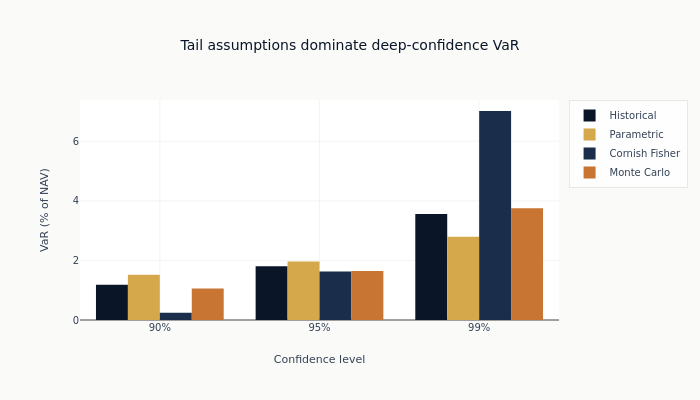

In [12]:
fig = go.Figure()
x = [f"{round(c * 100)}%" for c in confidence_levels]
for method in ["historical", "parametric", "cornish_fisher", "monte_carlo"]:
    fig.add_trace(go.Bar(x=x, y=var_df[method], name=method.replace("_", " ").title()))
fig.update_layout(
    title="Tail assumptions dominate deep-confidence VaR",
    xaxis=dict(title="Confidence level", type="category"),
    yaxis_title="VaR (% of NAV)",
    barmode="group",
    height=400,
)
fig.show()

## 3. Conditional Value at Risk (CVaR / Expected Shortfall)

CVaR is the average loss conditional on a VaR breach. Unlike VaR, CVaR is subadditive
and provides full-tail information - both properties that make it the preferred
coherent risk measure when tail severity matters more than tail frequency.

### Historical CVaR

Historical CVaR averages the realized losses that fall beyond the VaR threshold.

In [13]:
def historical_cvar(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Historical CVaR (Expected Shortfall): $\\mathbb{E}[L \\mid L \\geq \\text{VaR}_\\alpha]$."""
    alpha = 1 - confidence
    var_q = np.percentile(returns, alpha * 100)
    tail_losses = returns[returns <= var_q]
    return -np.mean(tail_losses)

### Parametric CVaR

Parametric CVaR extends the Gaussian assumption to estimate expected tail losses analytically.

In [14]:
def parametric_cvar(returns: np.ndarray, confidence: float = 0.95) -> float:
    """Parametric (Gaussian) CVaR: $-\\mu + \\sigma \\frac{\\phi(\\Phi^{-1}(1-\\alpha))}{\\alpha}$."""
    mu = np.mean(returns)
    sigma = np.std(returns)
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha)
    phi_z = stats.norm.pdf(z)
    return -(mu - sigma * phi_z / alpha)

### Student-t CVaR

Student-t CVaR captures heavier tails than the Gaussian alternative.

In [15]:
def student_t_cvar(returns: np.ndarray, confidence: float = 0.95) -> float:
    """CVaR under a fitted Student-t distribution (closed-form expression)."""
    df, loc, scale = stats.t.fit(returns)
    alpha = 1 - confidence
    t_val = stats.t.ppf(alpha, df)
    f_t = stats.t.pdf(t_val, df)
    return -loc + scale * (df + t_val**2) / ((df - 1) * alpha) * f_t

### Comparing VaR with CVaR

In [16]:
risk_measures = []
for conf in confidence_levels:
    risk_measures.append(
        {
            "confidence": conf,
            "var_historical": historical_var(returns, conf) * 100,
            "cvar_historical": historical_cvar(returns, conf) * 100,
            "var_parametric": parametric_var(returns, conf) * 100,
            "cvar_parametric": parametric_cvar(returns, conf) * 100,
            "cvar_student_t": student_t_cvar(returns, conf) * 100,
        }
    )
risk_df = pl.DataFrame(risk_measures)

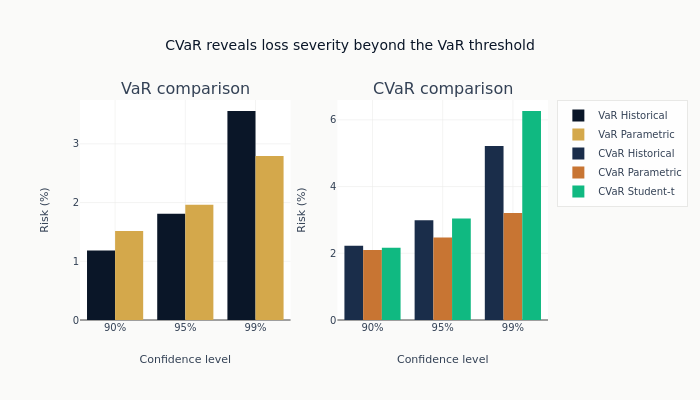

In [17]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["VaR comparison", "CVaR comparison"])
fig.add_trace(go.Bar(x=x, y=risk_df["var_historical"], name="VaR Historical"), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=risk_df["var_parametric"], name="VaR Parametric"), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=risk_df["cvar_historical"], name="CVaR Historical"), row=1, col=2)
fig.add_trace(go.Bar(x=x, y=risk_df["cvar_parametric"], name="CVaR Parametric"), row=1, col=2)
fig.add_trace(go.Bar(x=x, y=risk_df["cvar_student_t"], name="CVaR Student-t"), row=1, col=2)
fig.update_yaxes(title_text="Risk (%)", row=1, col=1)
fig.update_yaxes(title_text="Risk (%)", row=1, col=2)
for col in [1, 2]:
    fig.update_xaxes(
        title_text="Confidence level",
        type="category",
        tickmode="array",
        tickvals=x,
        ticktext=x,
        row=1,
        col=col,
    )
fig.update_layout(
    title="CVaR reveals loss severity beyond the VaR threshold", barmode="group", height=400
)
fig.show()

CVaR systematically exceeds VaR at every confidence level, by a factor that grows in
the tail: the gap between Historical VaR(99%) and Historical CVaR(99%) is larger than
the corresponding gap at 90%. Student-t CVaR sits above the Gaussian estimate at deep
confidence, reflecting the heavier-tailed empirical distribution.

## 3.1 Cantelli Inequality: Distribution-Free Tail Bound

The Cantelli (one-sided Chebyshev) inequality provides a worst-case tail probability
requiring only finite mean and variance - no distributional assumptions:

$$P(X - \mu \geq k\sigma) \leq \frac{1}{1 + k^2}$$

This is much weaker than Gaussian bounds but applies to *any* distribution, making it
useful as a conservative stress benchmark when distribution assumptions are suspect.

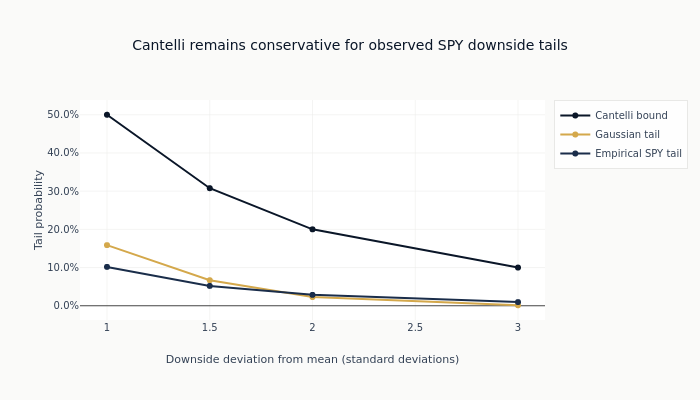

In [18]:
k_values = [1.0, 1.5, 2.0, 3.0]
standardized_losses = (np.mean(returns) - returns) / np.std(returns)
cantelli_df = pl.DataFrame(
    {
        "k": k_values,
        "cantelli_bound": [1.0 / (1.0 + k**2) for k in k_values],
        "gaussian_tail": [1.0 - stats.norm.cdf(k) for k in k_values],
        "empirical_spy_tail": [np.mean(standardized_losses >= k) for k in k_values],
    }
).with_columns(pl.exclude("k").round(4))

fig = go.Figure()
for column, label in [
    ("cantelli_bound", "Cantelli bound"),
    ("gaussian_tail", "Gaussian tail"),
    ("empirical_spy_tail", "Empirical SPY tail"),
]:
    fig.add_trace(go.Scatter(x=k_values, y=cantelli_df[column], mode="lines+markers", name=label))
fig.update_layout(
    title="Cantelli remains conservative for observed SPY downside tails",
    xaxis_title="Downside deviation from mean (standard deviations)",
    yaxis_title="Tail probability",
    yaxis_tickformat=".1%",
    height=400,
)
fig.show()

In [19]:
cantelli_k2 = cantelli_df.filter(pl.col("k") == 2.0).row(0, named=True)
display(
    Markdown(
        f"At $k=2$, the Cantelli bound is {cantelli_k2['cantelli_bound']:.1%}, "
        f"compared with {cantelli_k2['gaussian_tail']:.1%} under a Gaussian model and "
        f"{cantelli_k2['empirical_spy_tail']:.1%} in this SPY sample. The bound is "
        "distribution-free, but its conservatism limits its use as a day-to-day forecast."
    )
)

At $k=2$, the Cantelli bound is 20.0%, compared with 2.3% under a Gaussian model and 2.9% in this SPY sample. The bound is distribution-free, but its conservatism limits its use as a day-to-day forecast.

## 4. Distribution Analysis with ml4t-diagnostic

`analyze_distribution` and `analyze_tails` from `ml4t.diagnostic` package together the
moments, normality tests, Hill estimator, and QQ-plot diagnostics. This puts the
parametric / Cornish-Fisher / Student-t choice on an empirical footing.

In [20]:
dist_result = analyze_distribution(returns)
tail_analysis = dist_result.tail_analysis_result
distribution_summary = pl.DataFrame(
    {
        "metric": [
            "Jarque-Bera p-value",
            "Shapiro-Wilk p-value",
            "Hill tail index",
            "Normal QQ R-squared",
            "Student-t QQ R-squared",
            "Recommended distribution",
        ],
        "value": [
            f"{dist_result.jarque_bera_result.p_value:.4g}",
            f"{dist_result.shapiro_wilk_result.p_value:.4g}",
            f"{tail_analysis.hill_result.tail_index:.3f}",
            f"{tail_analysis.qq_normal.r_squared:.3f}",
            f"{tail_analysis.qq_t.r_squared:.3f}",
            dist_result.recommended_distribution,
        ],
    }
)
distribution_summary

metric,value
str,str
"""Jarque-Bera p-value""","""0"""
"""Shapiro-Wilk p-value""","""1.065e-52"""
"""Hill tail index""","""2.862"""
"""Normal QQ R-squared""","""0.870"""
"""Student-t QQ R-squared""","""0.993"""
"""Recommended distribution""","""t"""


## 5. VaR Backtesting

A VaR estimate is only as good as its empirical exception rate. The Kupiec
proportion-of-failures test compares the realized exception rate to the configured
coverage level under a binomial null.

### Kupiec proportion-of-failures test

In [21]:
def kupiec_test(exceptions: np.ndarray, expected_rate: float) -> tuple[float, float]:
    """Return the Kupiec likelihood-ratio statistic and its p-value."""
    n = len(exceptions)
    x = int(np.sum(exceptions))
    p = expected_rate
    if x == 0:
        lr = -2 * n * np.log(1 - p)
    elif x == n:
        lr = -2 * n * np.log(p)
    else:
        lr = 2 * (x * np.log(x / (n * p)) + (n - x) * np.log((n - x) / (n * (1 - p))))
    return lr, 1 - stats.chi2.cdf(lr, 1)

### Rolling VaR backtest helper

In [22]:
def backtest_var(
    returns: np.ndarray,
    window: int = ROLLING_WINDOW,
    confidence: float = 0.95,
    method: str = "historical",
) -> dict:
    """Backtest rolling VaR estimates against realized one-step losses."""
    var_func = {
        "historical": historical_var,
        "parametric": parametric_var,
        "cornish_fisher": cornish_fisher_var,
    }[method]

    var_estimates, exceptions = [], []
    for i in range(window, len(returns)):
        past = returns[i - window : i]
        v = var_func(past, confidence)
        var_estimates.append(v)
        exceptions.append(-returns[i] > v)

    var_estimates = np.array(var_estimates)
    exceptions = np.array(exceptions)
    n_exc = int(exceptions.sum())
    rate = n_exc / len(exceptions)
    expected = 1 - confidence
    lr, p_value = kupiec_test(exceptions, expected)

    return {
        "method": method,
        "n_observations": len(exceptions),
        "n_exceptions": n_exc,
        "exception_rate": rate,
        "expected_rate": expected,
        "exception_ratio": rate / expected,
        "kupiec_pvalue": p_value,
        "var_estimates": var_estimates,
        "exceptions": exceptions,
    }

In [23]:
backtest_results = []
for method in ["historical", "parametric", "cornish_fisher"]:
    backtest_results.append(
        backtest_var(returns, window=ROLLING_WINDOW, confidence=0.95, method=method)
    )

backtest_summary = pl.DataFrame(
    [
        {
            "method": r["method"],
            "exceptions": r["n_exceptions"],
            "rate_pct": r["exception_rate"] * 100,
            "ratio": r["exception_ratio"],
            "kupiec_p": r["kupiec_pvalue"],
            "reject_5pct": bool(r["kupiec_pvalue"] < 0.05),
        }
        for r in backtest_results
    ]
).with_columns(
    pl.col("rate_pct").round(4),
    pl.col("ratio").round(4),
    pl.col("kupiec_p").round(4),
)
backtest_summary

method,exceptions,rate_pct,ratio,kupiec_p,reject_5pct
str,i64,f64,f64,f64,bool
"""historical""",251,5.5433,1.1087,0.099,false
"""parametric""",264,5.8304,1.1661,0.0124,true
"""cornish_fisher""",263,5.8083,1.1617,0.0149,true


The exception ratio measures distance from the configured coverage target; the Kupiec test
asks whether that distance is statistically distinguishable from correct unconditional
coverage. Failure to reject is evidence about coverage, not proof that a model is valid.

In [24]:
best_result = min(backtest_results, key=lambda r: abs(r["exception_ratio"] - 1))
backtest_by_method = {result["method"]: result for result in backtest_results}
historical_result = backtest_by_method["historical"]
parametric_result = backtest_by_method["parametric"]
cornish_fisher_result = backtest_by_method["cornish_fisher"]
display(
    Markdown(
        f"Historical VaR has an exception ratio of {historical_result['exception_ratio']:.2f} "
        f"with Kupiec $p={historical_result['kupiec_pvalue']:.3f}$. Parametric and "
        f"Cornish-Fisher VaR produce ratios of {parametric_result['exception_ratio']:.2f} "
        f"and {cornish_fisher_result['exception_ratio']:.2f}; their Kupiec p-values are "
        f"{parametric_result['kupiec_pvalue']:.3f} and "
        f"{cornish_fisher_result['kupiec_pvalue']:.3f}."
    )
)

Historical VaR has an exception ratio of 1.11 with Kupiec $p=0.099$. Parametric and Cornish-Fisher VaR produce ratios of 1.17 and 1.16; their Kupiec p-values are 0.012 and 0.015.

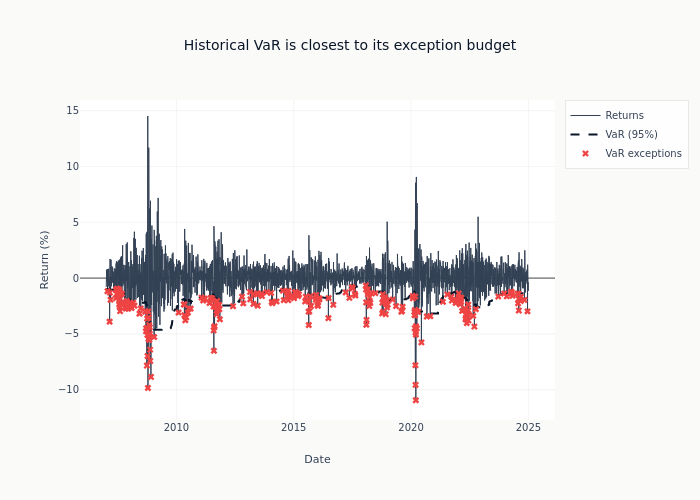

In [25]:
test_dates = dates[ROLLING_WINDOW:]
test_returns = returns[ROLLING_WINDOW:]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=test_dates,
        y=test_returns * 100,
        mode="lines",
        name="Returns",
        line=dict(color=COLORS["neutral"], width=1),
    )
)
fig.add_trace(
    go.Scatter(
        x=test_dates,
        y=-best_result["var_estimates"] * 100,
        mode="lines",
        name="VaR (95%)",
        line=dict(color=COLORS["blue"], dash="dash"),
    )
)
mask = best_result["exceptions"]
fig.add_trace(
    go.Scatter(
        x=test_dates[mask],
        y=test_returns[mask] * 100,
        mode="markers",
        name="VaR exceptions",
        marker=dict(color=COLORS["negative"], size=6, symbol="x"),
    )
)
fig.update_layout(
    title=f"{best_result['method'].title()} VaR is closest to its exception budget",
    xaxis_title="Date",
    yaxis_title="Return (%)",
    height=500,
)
fig.show()

## 6. Rolling VaR and CVaR

In [26]:
rolling_var, rolling_cvar = [], []
for i in range(ROLLING_WINDOW, len(returns)):
    past = returns[i - ROLLING_WINDOW : i]
    rolling_var.append(historical_var(past, 0.95))
    rolling_cvar.append(historical_cvar(past, 0.95))
rolling_var = np.array(rolling_var)
rolling_cvar = np.array(rolling_cvar)
rolling_dates = dates[ROLLING_WINDOW:]

rolling_summary = pl.DataFrame(
    {
        "metric": ["Mean VaR(95%)", "Mean CVaR(95%)", "Mean CVaR/VaR ratio"],
        "value": [
            f"{np.mean(rolling_var) * 100:.3f}%",
            f"{np.mean(rolling_cvar) * 100:.3f}%",
            f"{np.mean(rolling_cvar) / np.mean(rolling_var):.2f}x",
        ],
    }
)
rolling_summary

metric,value
str,str
"""Mean VaR(95%)""","""1.839%"""
"""Mean CVaR(95%)""","""2.635%"""
"""Mean CVaR/VaR ratio""","""1.43x"""


In [27]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, subplot_titles=["Rolling VaR and CVaR", "CVaR / VaR ratio"]
)
fig.add_trace(
    go.Scatter(
        x=rolling_dates,
        y=rolling_var * 100,
        mode="lines",
        name="VaR 95%",
        line=dict(color=COLORS["blue"]),
    ),
    row=1,
    col=1,
)
_ = fig

Both series use a trailing 252-trading-day window of daily, unannualized returns. The lower
panel normalizes expected shortfall by VaR to show changes in tail severity that are not
explained by a larger loss threshold alone.

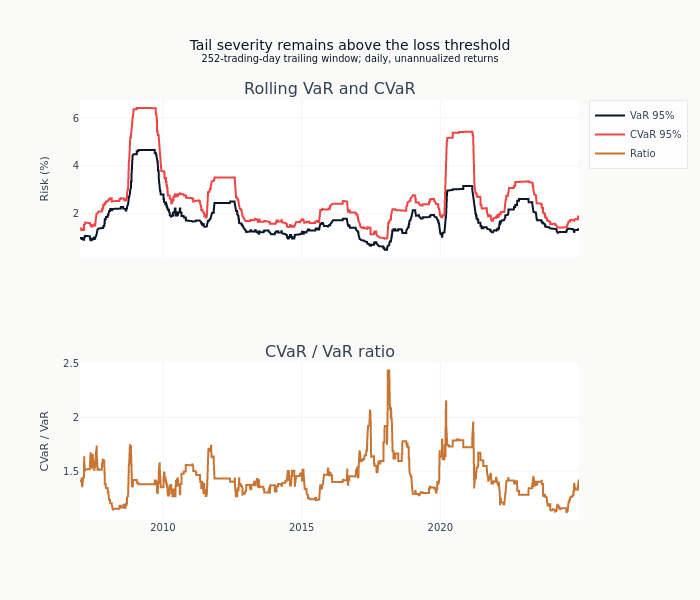

In [28]:
fig.add_trace(
    go.Scatter(
        x=rolling_dates,
        y=rolling_cvar * 100,
        mode="lines",
        name="CVaR 95%",
        line=dict(color=COLORS["negative"]),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=rolling_dates,
        y=rolling_cvar / rolling_var,
        mode="lines",
        name="Ratio",
        line=dict(color=COLORS["copper"]),
    ),
    row=2,
    col=1,
)
fig.update_yaxes(title_text="Risk (%)", row=1, col=1)
fig.update_yaxes(title_text="CVaR / VaR", row=2, col=1)
fig.update_layout(
    title=(
        "Tail severity remains above the loss threshold"
        "<br><sup>252-trading-day trailing window; daily, unannualized returns</sup>"
    ),
    height=600,
)
fig.show()

## 6.1 Regime-Conditional VaR and CVaR

Unconditional VaR averages over regimes and masks the tail amplification that occurs
during high-volatility periods. Each day uses prior-close 63-trading-day daily volatility
and expanding point-in-time tercile thresholds available at that time. The same-day return
never defines its own regime.

In [29]:
regime_frame = returns_spy.with_columns(
    rolling_vol=pl.col("ret").rolling_std(window_size=REGIME_WINDOW).shift(1)
)
rolling_vol = regime_frame["rolling_vol"].to_numpy()
low_threshold = np.full(len(rolling_vol), np.nan)
high_threshold = np.full(len(rolling_vol), np.nan)
regimes = np.full(len(rolling_vol), None, dtype=object)

At each date, the expanding thresholds use only lagged volatility observations already
available by that morning. The minimum history avoids unstable early-sample terciles.

In [30]:
for i, current_vol in enumerate(rolling_vol):
    available_history = rolling_vol[: i + 1]
    available_history = available_history[np.isfinite(available_history)]
    if np.isfinite(current_vol) and len(available_history) >= REGIME_MIN_HISTORY:
        low_threshold[i], high_threshold[i] = np.quantile(available_history, [0.33, 0.67])
        regimes[i] = (
            "Low Vol"
            if current_vol <= low_threshold[i]
            else "Mid Vol"
            if current_vol <= high_threshold[i]
            else "High Vol"
        )

valid_regimes = np.array([regime is not None for regime in regimes])
vol_dates = dates[valid_regimes]
vol_returns = returns[valid_regimes]
regimes = regimes[valid_regimes]

regime_rows = []
regime_stats = {}
for regime in ["Low Vol", "Mid Vol", "High Vol"]:
    mask = regimes == regime
    regime_ret = vol_returns[mask]
    var_val = historical_var(regime_ret, 0.95) * 100
    cvar_val = historical_cvar(regime_ret, 0.95) * 100
    regime_stats[regime] = {"var": var_val, "cvar": cvar_val, "n": int(mask.sum())}
    regime_rows.append(
        {
            "regime": regime,
            "n_days": int(mask.sum()),
            "var_95_pct": var_val,
            "cvar_95_pct": cvar_val,
            "cvar_var_ratio": cvar_val / var_val,
        }
    )
regime_df = pl.DataFrame(regime_rows).with_columns(pl.exclude("regime").round(3))

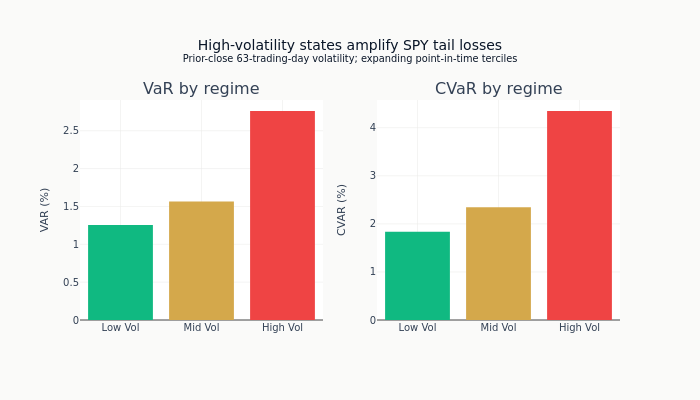

In [31]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["VaR by regime", "CVaR by regime"])
regime_names = list(regime_stats.keys())
colors = [COLORS["positive"], COLORS["amber"], COLORS["negative"]]
for col_i, metric in enumerate(["var", "cvar"], 1):
    vals = [regime_stats[r][metric] for r in regime_names]
    fig.add_trace(
        go.Bar(x=regime_names, y=vals, marker_color=colors, showlegend=False),
        row=1,
        col=col_i,
    )
    fig.update_yaxes(title_text=f"{metric.upper()} (%)", row=1, col=col_i)
fig.update_layout(
    title=(
        "High-volatility states amplify SPY tail losses"
        "<br><sup>Prior-close 63-trading-day volatility; expanding point-in-time terciles</sup>"
    ),
    height=400,
)
fig.show()

In [32]:
low_vol_stats = regime_stats["Low Vol"]
high_vol_stats = regime_stats["High Vol"]
display(
    Markdown(
        f"CVaR rises from {low_vol_stats['cvar']:.2f}% in the low-volatility state to "
        f"{high_vol_stats['cvar']:.2f}% in the high-volatility state, a "
        f"{high_vol_stats['cvar'] / low_vol_stats['cvar']:.1f}x increase. Because each "
        "label is available before the return it classifies, a risk control can use this "
        "state without same-bar look-ahead."
    )
)

CVaR rises from 1.83% in the low-volatility state to 4.35% in the high-volatility state, a 2.4x increase. Because each label is available before the return it classifies, a risk control can use this state without same-bar look-ahead.

## 6.2 Drawdown depth and time-to-recovery

VaR and CVaR are point-loss measures; drawdowns capture *path* risk - how deep the
losses go and how long the recovery takes. For the same underlying return series,
drawdowns and tail measures stress different aspects of the same distribution.

In [33]:
def drawdown_path(returns: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return cumulative wealth, running peak, and drawdown (negative %) series."""
    wealth = np.cumprod(1 + returns)
    peak = np.maximum.accumulate(wealth)
    dd = wealth / peak - 1
    return wealth, peak, dd


wealth, peak, drawdown = drawdown_path(returns)
max_dd = float(drawdown.min())
max_dd_idx = int(drawdown.argmin())
peak_idx = int(np.argmax(wealth[: max_dd_idx + 1]))
recovery_offset = np.where(wealth[max_dd_idx:] >= peak[max_dd_idx])[0]
recovery_idx = int(max_dd_idx + recovery_offset[0]) if recovery_offset.size else None

drawdown_summary = pl.DataFrame(
    {
        "metric": [
            "Max drawdown",
            "Max-drawdown trough date",
            "Prior peak date",
            "Recovery date",
            "Drawdown duration (trading days)",
            "Recovery duration (trading days)",
        ],
        "value": [
            f"{max_dd * 100:.2f}%",
            str(pd.Timestamp(dates[max_dd_idx]).date()),
            str(pd.Timestamp(dates[peak_idx]).date()),
            str(pd.Timestamp(dates[recovery_idx]).date())
            if recovery_idx is not None
            else "not recovered in sample",
            str(max_dd_idx - peak_idx),
            str(recovery_idx - max_dd_idx) if recovery_idx is not None else "not recovered",
        ],
    }
)
drawdown_summary

metric,value
str,str
"""Max drawdown""","""-55.19%"""
"""Max-drawdown trough date""","""2009-03-09"""
"""Prior peak date""","""2007-10-09"""
"""Recovery date""","""2012-08-16"""
"""Drawdown duration (trading days)""","""355"""
"""Recovery duration (trading days)""","""869"""


In [34]:
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True, subplot_titles=[f"{SYMBOL} growth of $1", "Drawdown"]
)
fig.add_trace(
    go.Scatter(x=dates, y=wealth, mode="lines", name="Wealth", line=dict(color=COLORS["blue"])),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=peak,
        mode="lines",
        name="Peak",
        line=dict(color=COLORS["neutral"], dash="dash"),
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=drawdown * 100,
        mode="lines",
        name="Drawdown",
        fill="tozeroy",
        line=dict(color=COLORS["negative"]),
    ),
    row=2,
    col=1,
)
_ = fig

The message title reports the observed depth and recovery, while the drawdown panel retains
the conventional zero-at-top orientation.

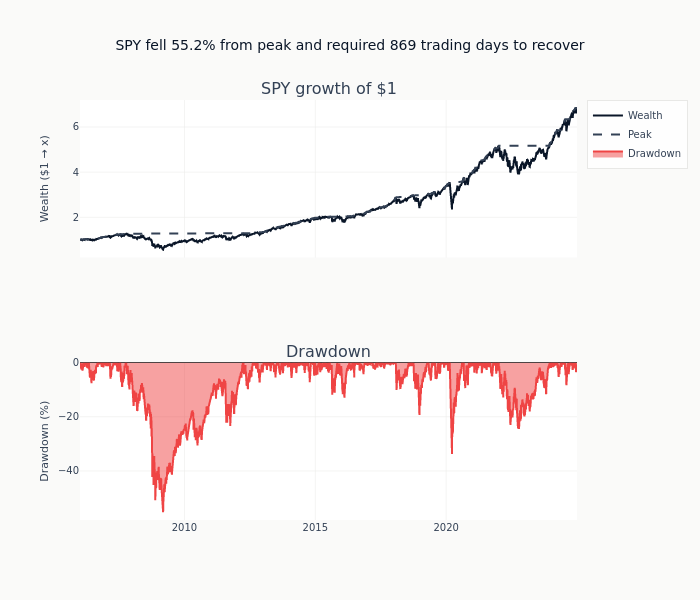

In [35]:
fig.update_yaxes(title_text="Wealth ($1 → x)", row=1, col=1)
fig.update_yaxes(title_text="Drawdown (%)", row=2, col=1)
recovery_days = recovery_idx - max_dd_idx if recovery_idx is not None else None
recovery_message = (
    f"and required {recovery_days:,} trading days to recover"
    if recovery_days is not None
    else "and remained unrecovered at the sample end"
)
fig.update_layout(
    title=f"{SYMBOL} fell {abs(max_dd):.1%} from peak {recovery_message}",
    height=600,
    showlegend=True,
)
fig.show()

Maximum drawdown is the worst-case path loss in the sample; the trough-to-recovery
duration is the operational pain that allocators and risk officers actually live
through. Tail metrics (CVaR) and path metrics (max drawdown) tend to move together
but the path metric responds to the *sequence* of losses - two distributions with
identical CVaR can produce very different drawdown experiences.

## 7. Portfolio VaR - Diversification Benefit

The gap between this portfolio's tail risk and the weighted stand-alone estimates measures
its empirical diversification benefit. Unlike CVaR, VaR is not generally subadditive, so a
positive VaR benefit in this sample is an observation rather than a mathematical guarantee.

In [36]:
def portfolio_tail_risk(
    returns_matrix: np.ndarray,
    weights: np.ndarray,
    confidence: float = 0.95,
) -> dict:
    """Compute empirical portfolio VaR and CVaR against weighted stand-alone estimates."""
    portfolio_returns = returns_matrix @ weights
    individual_var = np.array(
        [historical_var(returns_matrix[:, i], confidence) for i in range(returns_matrix.shape[1])]
    )
    individual_cvar = np.array(
        [historical_cvar(returns_matrix[:, i], confidence) for i in range(returns_matrix.shape[1])]
    )
    undiversified_var = float(np.sum(weights * individual_var))
    undiversified_cvar = float(np.sum(weights * individual_cvar))
    diversified_var = float(historical_var(portfolio_returns, confidence))
    diversified_cvar = float(historical_cvar(portfolio_returns, confidence))
    return {
        "portfolio_var": diversified_var,
        "portfolio_cvar": diversified_cvar,
        "undiversified_var": undiversified_var,
        "undiversified_cvar": undiversified_cvar,
        "var_benefit": 1 - diversified_var / undiversified_var,
        "cvar_benefit": 1 - diversified_cvar / undiversified_cvar,
        "portfolio_returns": portfolio_returns,
    }

In [37]:
asset_returns = returns_wide.select(PORTFOLIO_SYMBOLS).to_numpy()
weights = np.ones(len(PORTFOLIO_SYMBOLS)) / len(PORTFOLIO_SYMBOLS)
port_var_result = portfolio_tail_risk(asset_returns, weights, confidence=0.95)

portfolio_summary = pl.DataFrame(
    {
        "metric": ["VaR", "CVaR"],
        "portfolio_pct": [
            port_var_result["portfolio_var"] * 100,
            port_var_result["portfolio_cvar"] * 100,
        ],
        "weighted_standalone_pct": [
            port_var_result["undiversified_var"] * 100,
            port_var_result["undiversified_cvar"] * 100,
        ],
    }
)

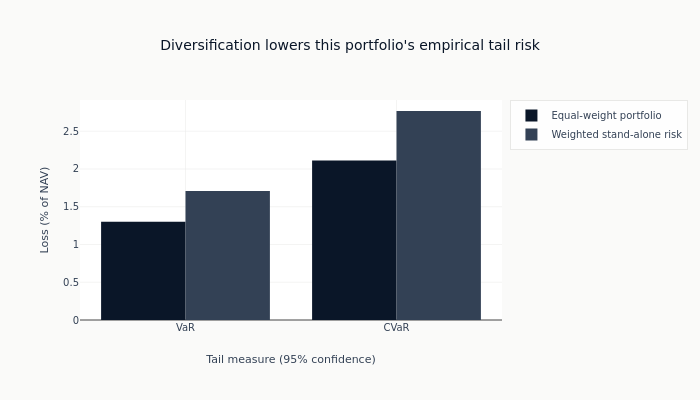

In [38]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=portfolio_summary["metric"],
        y=portfolio_summary["portfolio_pct"],
        name="Equal-weight portfolio",
        marker_color=COLORS["blue"],
    )
)
fig.add_trace(
    go.Bar(
        x=portfolio_summary["metric"],
        y=portfolio_summary["weighted_standalone_pct"],
        name="Weighted stand-alone risk",
        marker_color=COLORS["neutral"],
    )
)
fig.update_layout(
    title="Diversification lowers this portfolio's empirical tail risk",
    xaxis_title="Tail measure (95% confidence)",
    yaxis_title="Loss (% of NAV)",
    barmode="group",
    height=400,
)
fig.show()

In [39]:
display(
    Markdown(
        f"The equal-weight portfolio's VaR is {port_var_result['portfolio_var']:.2%}, "
        f"compared with {port_var_result['undiversified_var']:.2%} for the weighted "
        f"stand-alone estimates, an empirical benefit of {port_var_result['var_benefit']:.1%}. "
        f"CVaR falls by {port_var_result['cvar_benefit']:.1%}; unlike VaR, this benefit is "
        "consistent with CVaR's general subadditivity property."
    )
)

The equal-weight portfolio's VaR is 1.30%, compared with 1.71% for the weighted stand-alone estimates, an empirical benefit of 23.9%. CVaR falls by 23.7%; unlike VaR, this benefit is consistent with CVaR's general subadditivity property.

### Diversification across point-in-time volatility states

Applying the causal SPY state labels to the aligned ETF panel tests whether the observed
VaR benefit survives high-volatility days. The state is known before each portfolio return.

In [40]:
regime_labels = pl.DataFrame({"timestamp": vol_dates, "regime": regimes})
portfolio_by_regime = returns_wide.join(regime_labels, on="timestamp", how="inner")
regime_portfolio_rows = []
for regime in ["Low Vol", "Mid Vol", "High Vol"]:
    regime_matrix = portfolio_by_regime.filter(pl.col("regime") == regime).select(PORTFOLIO_SYMBOLS)
    result = portfolio_tail_risk(regime_matrix.to_numpy(), weights, confidence=0.95)
    regime_portfolio_rows.append(
        {
            "regime": regime,
            "n_days": regime_matrix.height,
            "var_benefit_pct": result["var_benefit"] * 100,
            "cvar_benefit_pct": result["cvar_benefit"] * 100,
        }
    )
regime_portfolio_df = pl.DataFrame(regime_portfolio_rows)

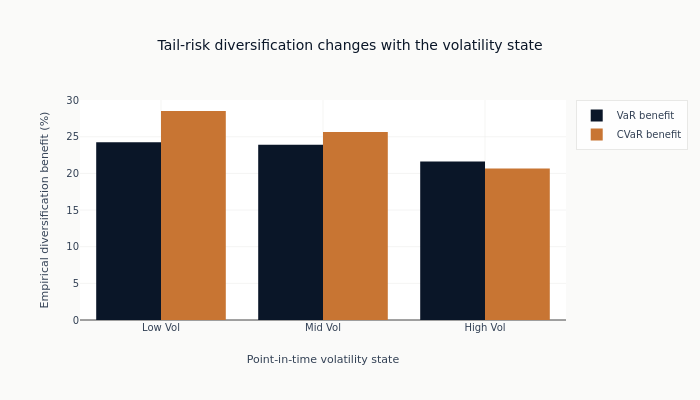

In [41]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        x=regime_portfolio_df["regime"],
        y=regime_portfolio_df["var_benefit_pct"],
        name="VaR benefit",
        marker_color=COLORS["blue"],
    )
)
fig.add_trace(
    go.Bar(
        x=regime_portfolio_df["regime"],
        y=regime_portfolio_df["cvar_benefit_pct"],
        name="CVaR benefit",
        marker_color=COLORS["copper"],
    )
)
fig.update_layout(
    title="Tail-risk diversification changes with the volatility state",
    xaxis_title="Point-in-time volatility state",
    yaxis_title="Empirical diversification benefit (%)",
    barmode="group",
    height=400,
)
fig.show()

In [42]:
regime_portfolio_lookup = {row["regime"]: row for row in regime_portfolio_df.iter_rows(named=True)}
low_regime_benefit = regime_portfolio_lookup["Low Vol"]["cvar_benefit_pct"]
high_regime_benefit = regime_portfolio_lookup["High Vol"]["cvar_benefit_pct"]
benefit_direction = "contracts" if high_regime_benefit < low_regime_benefit else "expands"
display(
    Markdown(
        f"The empirical CVaR benefit {benefit_direction} from {low_regime_benefit:.1f}% "
        f"in the low-volatility state to {high_regime_benefit:.1f}% in the "
        "high-volatility state. The result is sample-specific; the point-in-time labels "
        "make the comparison usable as a diagnostic rather than a look-ahead mechanism."
    )
)

The empirical CVaR benefit contracts from 28.5% in the low-volatility state to 20.7% in the high-volatility state. The result is sample-specific; the point-in-time labels make the comparison usable as a diagnostic rather than a look-ahead mechanism.

## 8. Volatility Forecast Evaluation: QLIKE and MSE

Risk management depends on accurate volatility forecasts. Two complementary loss
functions evaluate forecast quality:

$$\text{MSE} = \frac{1}{T}\sum_{t=1}^T (\hat{\sigma}_t^2 - \sigma_t^2)^2$$

$$\text{QLIKE} = \frac{1}{T}\sum_{t=1}^T \left[\log(\hat{\sigma}_t^2) + \frac{\sigma_t^2}{\hat{\sigma}_t^2}\right]$$

QLIKE's asymmetric penalty makes it more appropriate for risk: under-predicting
volatility (dangerous for risk management) is penalized more than over-predicting.
We use squared daily returns as the volatility proxy $\sigma_t^2$. See Chapter 9 for
deeper GARCH treatment; here we use a compact GARCH(1,1) fit solely for comparison.

### QLIKE Loss

QLIKE penalizes under-forecasting volatility more sharply than over-forecasting it.

In [43]:
def qlike_loss(forecast_var: np.ndarray, proxy_var: np.ndarray) -> float:
    """QLIKE loss: $\\log(\\hat{\\sigma}^2) + \\sigma^2_{\\text{proxy}} / \\hat{\\sigma}^2$."""
    mask = (forecast_var > 0) & np.isfinite(forecast_var) & np.isfinite(proxy_var)
    f, p = forecast_var[mask], proxy_var[mask]
    return float(np.mean(np.log(f) + p / f))

### Variance MSE

MSE provides a symmetric baseline loss for volatility forecast comparison.

In [44]:
def variance_mse(forecast_var: np.ndarray, proxy_var: np.ndarray) -> float:
    """Variance MSE: $(\\hat{\\sigma}^2 - \\sigma^2_{\\text{proxy}})^2$."""
    return float(np.mean((forecast_var - proxy_var) ** 2))

In [45]:
ret_series = pd.Series(returns, index=pd.DatetimeIndex(dates))
proxy_var = ret_series**2

# Rolling and EWMA variance for day t use returns only through t-1. GARCH parameters are
# estimated once on observations before the evaluation boundary; the fixed model then updates
# conditional variance recursively as evaluation-period returns arrive.
rolling_var_21 = ret_series.rolling(21).var().shift(1).dropna()
ewma_var = ret_series.ewm(alpha=0.06).var().shift(1).dropna()
garch_model = arch_model(ret_series * 100, vol="Garch", p=1, q=1, dist="normal")
garch_fit = garch_model.fit(last_obs=FORECAST_EVALUATION_START, disp="off")
garch_forecast = garch_fit.forecast(
    horizon=1,
    start=FORECAST_EVALUATION_START,
    align="target",
    reindex=True,
)
garch_var = (garch_forecast.variance["h.1"] / 10_000).dropna()

common_idx = rolling_var_21.index.intersection(ewma_var.index).intersection(garch_var.index)
common_idx = common_idx[common_idx >= pd.Timestamp(FORECAST_EVALUATION_START)]
proxy_aligned = proxy_var.loc[common_idx].values
rolling_aligned = rolling_var_21.loc[common_idx].values
ewma_aligned = ewma_var.loc[common_idx].values
garch_aligned = garch_var.loc[common_idx].values

forecast_eval_df = pl.DataFrame(
    [
        {
            "method": name,
            "qlike": qlike_loss(fcast, proxy_aligned),
            "mse_x_1e6": variance_mse(fcast, proxy_aligned) * 1e6,
        }
        for name, fcast in [
            ("Rolling 21d", rolling_aligned),
            ("EWMA λ=0.94", ewma_aligned),
            ("GARCH(1,1)", garch_aligned),
        ]
    ]
).with_columns(pl.exclude("method").round(4))

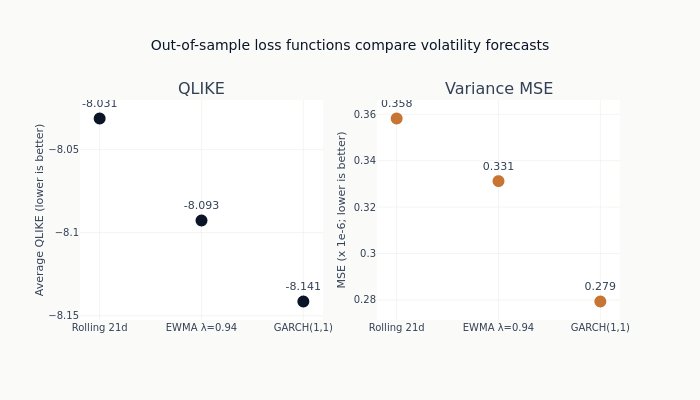

In [46]:
fig = make_subplots(rows=1, cols=2, subplot_titles=["QLIKE", "Variance MSE"])
fig.add_trace(
    go.Scatter(
        x=forecast_eval_df["method"],
        y=forecast_eval_df["qlike"],
        mode="markers+text",
        text=[f"{value:.3f}" for value in forecast_eval_df["qlike"]],
        textposition="top center",
        marker=dict(color=COLORS["blue"], size=12),
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(
        x=forecast_eval_df["method"],
        y=forecast_eval_df["mse_x_1e6"],
        mode="markers+text",
        text=[f"{value:.3f}" for value in forecast_eval_df["mse_x_1e6"]],
        textposition="top center",
        marker=dict(color=COLORS["copper"], size=12),
        showlegend=False,
    ),
    row=1,
    col=2,
)
fig.update_yaxes(title_text="Average QLIKE (lower is better)", row=1, col=1)
fig.update_yaxes(title_text="MSE (x 1e-6; lower is better)", row=1, col=2)
fig.update_layout(
    title="Out-of-sample loss functions compare volatility forecasts",
    height=400,
)
fig.show()

In [47]:
qlike_winner = forecast_eval_df.sort("qlike").row(0, named=True)
mse_winner = forecast_eval_df.sort("mse_x_1e6").row(0, named=True)
display(
    Markdown(
        f"From {common_idx.min().date()} through {common_idx.max().date()}, "
        f"{qlike_winner['method']} has the lowest QLIKE ({qlike_winner['qlike']:.3f}) and "
        f"{mse_winner['method']} has the lowest variance MSE "
        f"({mse_winner['mse_x_1e6']:.3f} x $10^{{-6}}$). GARCH parameters are estimated "
        "before this interval, while rolling and EWMA forecasts are explicitly lagged. "
        "Squared returns remain a noisy volatility proxy, so small loss gaps should not be "
        "treated as economically decisive."
    )
)

From 2020-01-03 through 2024-12-31, GARCH(1,1) has the lowest QLIKE (-8.141) and GARCH(1,1) has the lowest variance MSE (0.279 x $10^{-6}$). GARCH parameters are estimated before this interval, while rolling and EWMA forecasts are explicitly lagged. Squared returns remain a noisy volatility proxy, so small loss gaps should not be treated as economically decisive.

## 9. Save artefacts for downstream chapters

In [48]:
var_comparison_df = pl.DataFrame(
    {
        "confidence": [f"{round(c * 100)}%" for c in confidence_levels] * 4,
        "method": ["historical"] * 3
        + ["parametric"] * 3
        + ["cornish_fisher"] * 3
        + ["monte_carlo"] * 3,
        "var_pct": list(var_df["historical"])
        + list(var_df["parametric"])
        + list(var_df["cornish_fisher"])
        + list(var_df["monte_carlo"]),
    }
)
var_cvar_df = risk_df
backtest_df = pl.DataFrame(
    {
        "method": [r["method"] for r in backtest_results],
        "n_exceptions": [r["n_exceptions"] for r in backtest_results],
        "n_observations": [r["n_observations"] for r in backtest_results],
        "exception_rate": [r["exception_rate"] for r in backtest_results],
        "expected_rate": [r["expected_rate"] for r in backtest_results],
        "exception_ratio": [r["exception_ratio"] for r in backtest_results],
        "kupiec_pvalue": [r["kupiec_pvalue"] for r in backtest_results],
    }
)
rolling_risk_df = pl.DataFrame(
    {
        "timestamp": pd.DatetimeIndex(rolling_dates).to_pydatetime().tolist(),
        "var_95": rolling_var.tolist(),
        "cvar_95": rolling_cvar.tolist(),
        "cvar_var_ratio": (rolling_cvar / rolling_var).tolist(),
    }
)
regime_pl = regime_df

The metadata captures the estimation boundaries and causal regime convention alongside the
reported values so downstream notebooks can audit how each result was produced.

In [49]:
best_bt = best_result
methodology_metadata = {
    "symbol": SYMBOL,
    "portfolio_symbols": PORTFOLIO_SYMBOLS,
    "start_date": str(returns_wide["timestamp"].min()),
    "end_date": str(returns_wide["timestamp"].max()),
    "n_days": int(N_DAYS),
    "return_skewness": float(stats.skew(returns)),
    "return_kurtosis": float(stats.kurtosis(returns)),
    "is_non_normal": bool(abs(stats.skew(returns)) > 0.5 or stats.kurtosis(returns) > 1),
    "avg_var_95": float(np.mean(rolling_var)),
    "avg_cvar_95": float(np.mean(rolling_cvar)),
    "cvar_var_ratio": float(np.mean(rolling_cvar) / np.mean(rolling_var)),
    "diversification_benefit": float(port_var_result["var_benefit"]),
    "cvar_diversification_benefit": float(port_var_result["cvar_benefit"]),
    "best_backtest_method": best_bt["method"],
    "kupiec_pvalue_best": float(best_bt["kupiec_pvalue"]),
    "regime_low_vol_cvar_pct": float(regime_stats["Low Vol"]["cvar"]),
    "regime_high_vol_cvar_pct": float(regime_stats["High Vol"]["cvar"]),
    "regime_method": "prior-close rolling volatility with expanding point-in-time terciles",
    "regime_window": REGIME_WINDOW,
    "regime_min_history": REGIME_MIN_HISTORY,
    "forecast_evaluation_start": str(common_idx.min().date()),
    "forecast_evaluation_end": str(common_idx.max().date()),
    "max_drawdown_pct": float(max_dd * 100),
    "drawdown_duration_days": int(max_dd_idx - peak_idx),
    "recovery_duration_days": (
        int(recovery_idx - max_dd_idx) if recovery_idx is not None else None
    ),
}

The write step uses `get_output_dir`, which redirects every artifact to the isolated validation
directory when `ML4T_OUTPUT_DIR` is set.

In [50]:
var_comparison_df.write_parquet(OUTPUT_DIR / "var_method_comparison.parquet")
var_cvar_df.write_parquet(OUTPUT_DIR / "var_cvar_comparison.parquet")
backtest_df.write_parquet(OUTPUT_DIR / "var_backtest_results.parquet")
rolling_risk_df.write_parquet(OUTPUT_DIR / "rolling_risk_metrics.parquet")
regime_pl.write_parquet(OUTPUT_DIR / "regime_conditional_risk.parquet")
regime_portfolio_df.write_parquet(OUTPUT_DIR / "regime_portfolio_diversification.parquet")
forecast_eval_df.write_parquet(OUTPUT_DIR / "volatility_forecast_evaluation.parquet")

with open(OUTPUT_DIR / "var_methodology_metadata.json", "w") as f:
    json.dump(methodology_metadata, f, indent=2)

print(f"[OK] VaR/CVaR artefacts saved to {OUTPUT_DIR}")
print(f"  - var_method_comparison.parquet: {len(var_comparison_df)} rows")
print(f"  - var_cvar_comparison.parquet:   {len(var_cvar_df)} rows")
print(f"  - var_backtest_results.parquet:  {len(backtest_df)} methods")
print(f"  - rolling_risk_metrics.parquet:  {len(rolling_risk_df)} days")
print(f"  - regime_conditional_risk.parquet: {len(regime_pl)} regimes")
print(f"  - regime_portfolio_diversification.parquet: {len(regime_portfolio_df)} regimes")
print(f"  - volatility_forecast_evaluation.parquet: {len(forecast_eval_df)} methods")

[OK] VaR/CVaR artefacts saved to /tmp/ml4t-ch19a-01-production-r8/ch19_var_cvar
  - var_method_comparison.parquet: 12 rows
  - var_cvar_comparison.parquet:   3 rows
  - var_backtest_results.parquet:  3 methods
  - rolling_risk_metrics.parquet:  4528 days
  - regime_conditional_risk.parquet: 3 regimes
  - regime_portfolio_diversification.parquet: 3 regimes
  - volatility_forecast_evaluation.parquet: 3 methods


In [51]:
high_low_cvar_ratio = high_vol_stats["cvar"] / low_vol_stats["cvar"]
display(
    Markdown(
        f"""## 10. Key Takeaways

1. **Coverage must be backtested.** {best_result["method"].title()} VaR is closest to the
   configured exception budget in this sample, with an exception ratio of
   {best_result["exception_ratio"]:.2f} and Kupiec $p={best_result["kupiec_pvalue"]:.3f}$.
2. **CVaR measures severity beyond VaR.** The equal-weight ETF basket shows an empirical
   CVaR diversification benefit of {port_var_result["cvar_benefit"]:.1%}; CVaR is generally
   subadditive, while VaR is not.
3. **Tail-shape adjustments require diagnostics.** Student-t and Cornish-Fisher estimates
   move away from Gaussian VaR at deep confidence, but the Cornish-Fisher polynomial becomes
   unstable under large excess kurtosis.
4. **Risk controls need causal states.** High-volatility CVaR is {high_low_cvar_ratio:.1f}x
   the low-volatility estimate when each label uses information available before the return.
5. **Forecast comparisons need an external window.** The volatility models are scored from
   {common_idx.min().date()} onward after GARCH estimation ends.

**Next**: [`06_stress_testing`](06_stress_testing.ipynb) challenges these tail-risk estimates
with named historical crises and constructed shocks.
"""
    )
)

## 10. Key Takeaways

1. **Coverage must be backtested.** Historical VaR is closest to the
   configured exception budget in this sample, with an exception ratio of
   1.11 and Kupiec $p=0.099$.
2. **CVaR measures severity beyond VaR.** The equal-weight ETF basket shows an empirical
   CVaR diversification benefit of 23.7%; CVaR is generally
   subadditive, while VaR is not.
3. **Tail-shape adjustments require diagnostics.** Student-t and Cornish-Fisher estimates
   move away from Gaussian VaR at deep confidence, but the Cornish-Fisher polynomial becomes
   unstable under large excess kurtosis.
4. **Risk controls need causal states.** High-volatility CVaR is 2.4x
   the low-volatility estimate when each label uses information available before the return.
5. **Forecast comparisons need an external window.** The volatility models are scored from
   2020-01-03 onward after GARCH estimation ends.

**Next**: [`06_stress_testing`](06_stress_testing.ipynb) challenges these tail-risk estimates
with named historical crises and constructed shocks.
